# 03 — Feature engineering with mobile-money-style behavioral proxies

This notebook transformed raw repayment, bill, and payment histories into behavioral features inspired by alternative-data credit scoring. The features were proxies, not genuine mobile-money variables. They were designed to make the modeling workflow close to what would be done with legitimate transaction histories.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project_package.config import ensure_project_dirs, PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, TARGET
from project_package.plotting import save_figure
from project_package.reporting import save_table

ensure_project_dirs()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

from project_package.data import load_processed_base, create_sample_mobile_money_events
from project_package.features import add_repayment_proxy_features, add_synthetic_mobile_money_aggregates

In [2]:
df = load_processed_base()
features_df = add_repayment_proxy_features(df)
print(features_df.shape)
features_df.head()

(30000, 49)


,credit_limit,sex,education,marriage,age,pay_status_sep,pay_status_aug,pay_status_jul,pay_status_jun,pay_status_may,pay_status_apr,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,default_next_month,proxy_recent_repayment_status,proxy_max_delinquency_6m,proxy_mean_delinquency_6m,proxy_delinquency_count_6m,proxy_severe_delinquency_count_6m,proxy_on_time_count_6m,proxy_total_bill_6m,proxy_total_payment_6m,proxy_total_payment_to_bill_6m,ratio_pay_amt_apr_to_bill_amt_apr,ratio_pay_amt_may_to_bill_amt_may,ratio_pay_amt_jun_to_bill_amt_jun,ratio_pay_amt_jul_to_bill_amt_jul,ratio_pay_amt_aug_to_bill_amt_aug,ratio_pay_amt_sep_to_bill_amt_sep,proxy_payment_ratio_mean_6m,proxy_payment_ratio_volatility_6m,proxy_payment_consistency_6m,proxy_bill_volatility_6m,proxy_payment_volatility_6m,proxy_utilization_mean_6m,proxy_utilization_max_6m,proxy_recent_payment_to_limit,proxy_recent_bill_to_limit,proxy_age_to_credit_limit
0,20000,female,university,married,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,2,2,-0.333333,2,2,4,7704,689,0.089434,0.000000,0.000000,0.000000,0.000000,0.222115,0.000000,0.037019,0.090678,0.166667,1761.633219,281.283072,0.064200,0.195650,0.000000,0.195650,0.001200
1,120000,female,university,single,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,-1,2,0.500000,2,2,4,17077,5000,0.292791,0.613309,0.000000,0.305623,0.372856,0.579710,0.000000,0.311916,0.268659,0.666667,637.967841,752.772653,0.023718,0.028792,0.000000,0.022350,0.000217
2,90000,female,university,single,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,0,0,0.000000,0,0,6,101653,11018,0.108388,0.321564,0.066899,0.069779,0.073752,0.106937,0.051917,0.115141,0.102736,1.000000,6064.518593,1569.815488,0.188246,0.324878,0.016867,0.324878,0.000378
3,50000,female,university,married,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,0,0,0.000000,0,0,6,231334,8388,0.036259,0.033844,0.036914,0.038850,0.024345,0.041859,0.042562,0.036396,0.006722,1.000000,10565.793518,478.058155,0.771113,0.985820,0.040000,0.939800,0.000740
4,50000,male,university,married,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,-1,0,-0.333333,0,0,6,109339,59049,0.540054,0.035492,0.035987,0.429799,0.279057,5.000000,0.232099,1.002072,1.964390,1.000000,10668.590074,13786.230736,0.364463,0.716700,0.040000,0.172340,0.001140


## Feature-family summary

The newly created proxy features summarized delinquency, repayment consistency, payment capacity, balance utilization, and volatility.

In [3]:
proxy_cols = [c for c in features_df.columns if c.startswith("proxy_")]
feature_summary = features_df[proxy_cols].describe().T.reset_index().rename(columns={"index": "feature"})
save_table(feature_summary, "03_proxy_feature_summary.csv")
feature_summary.head(20)

,feature,count,mean,std,min,25%,50%,75%,max
0,proxy_recent_repayment_status,30000.0,-0.016700,1.123802,-2.000000,-1.000000,0.000000,0.000000,8.000000e+00
1,proxy_max_delinquency_6m,30000.0,0.438733,1.345154,-2.000000,0.000000,0.000000,2.000000,8.000000e+00
2,proxy_mean_delinquency_6m,30000.0,-0.182439,0.982176,-2.000000,-0.833333,0.000000,0.000000,6.000000e+00
3,proxy_delinquency_count_6m,30000.0,0.834200,1.554303,0.000000,0.000000,0.000000,1.000000,6.000000e+00
4,proxy_severe_delinquency_count_6m,30000.0,0.710133,1.464712,0.000000,0.000000,0.000000,1.000000,6.000000e+00
5,proxy_on_time_count_6m,30000.0,5.165800,1.554303,0.000000,5.000000,6.000000,6.000000,6.000000e+00
6,proxy_total_bill_6m,30000.0,270086.741567,379495.362279,0.000000,28957.750000,126361.000000,342637.750000,5.263883e+06
7,proxy_total_payment_6m,30000.0,31651.392567,60827.677939,0.000000,6679.750000,14383.000000,33503.500000,3.764066e+06
8,proxy_total_payment_to_bill_6m,30000.0,0.372412,0.590650,0.000000,0.041100,0.086410,0.596847,5.000000e+00
9,proxy_payment_ratio_mean_6m,30000.0,0.397353,0.557997,0.000000,0.039220,0.074232,0.711369,3.333333e+00


## Relationship between proxy features and default

Default rates were inspected across quantile bins of selected proxy features. This helped check whether engineered features carried useful monotonic risk information.

In [4]:
selected_features = [
    "proxy_delinquency_count_6m",
    "proxy_total_payment_to_bill_6m",
    "proxy_payment_ratio_mean_6m",
    "proxy_utilization_mean_6m",
    "proxy_payment_consistency_6m",
]
rows = []
for feature in selected_features:
    temp = features_df[[feature, TARGET]].copy()
    if temp[feature].nunique() > 5:
        temp["bin"] = pd.qcut(temp[feature], q=5, duplicates="drop")
    else:
        temp["bin"] = temp[feature].astype(str)
    summary = temp.groupby("bin", observed=True)[TARGET].agg(count="size", default_rate="mean").reset_index()
    summary["feature"] = feature
    rows.append(summary)
feature_risk_table = pd.concat(rows, ignore_index=True)
save_table(feature_risk_table, "03_proxy_feature_default_rates.csv")
feature_risk_table.head(20)

,bin,count,default_rate,feature
0,"(-0.001, 1.0]",24357,0.150018,proxy_delinquency_count_6m
1,"(1.0, 6.0]",5643,0.528442,proxy_delinquency_count_6m
2,"(-0.001, 0.0385]",6000,0.308667,proxy_total_payment_to_bill_6m
3,"(0.0385, 0.0563]",6000,0.248667,proxy_total_payment_to_bill_6m
4,"(0.0563, 0.184]",6000,0.243333,proxy_total_payment_to_bill_6m
5,"(0.184, 0.773]",6000,0.156167,proxy_total_payment_to_bill_6m
6,"(0.773, 5.0]",6000,0.149167,proxy_total_payment_to_bill_6m
7,"(-0.001, 0.0367]",6000,0.294500,proxy_payment_ratio_mean_6m
8,"(0.0367, 0.0512]",6000,0.241833,proxy_payment_ratio_mean_6m
9,"(0.0512, 0.143]",6000,0.255000,proxy_payment_ratio_mean_6m


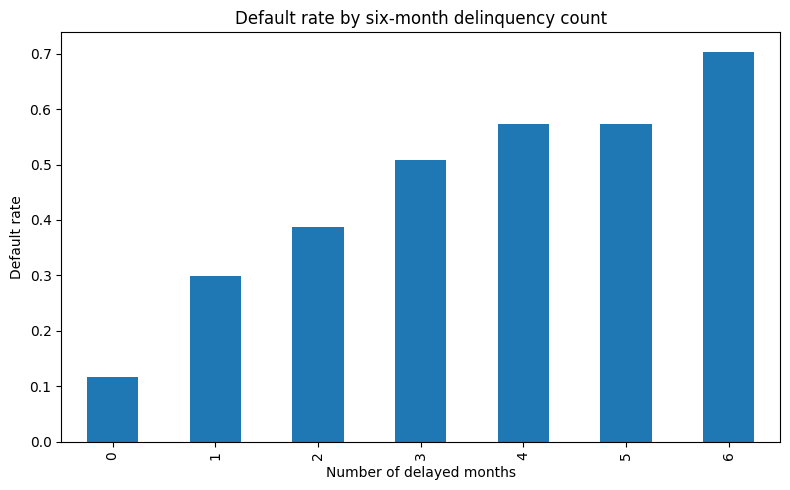

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
features_df.groupby("proxy_delinquency_count_6m")[TARGET].mean().plot(kind="bar", ax=ax)
ax.set_title("Default rate by six-month delinquency count")
ax.set_xlabel("Number of delayed months")
ax.set_ylabel("Default rate")
save_figure(fig, "03_default_rate_by_delinquency_count.png")
plt.show()

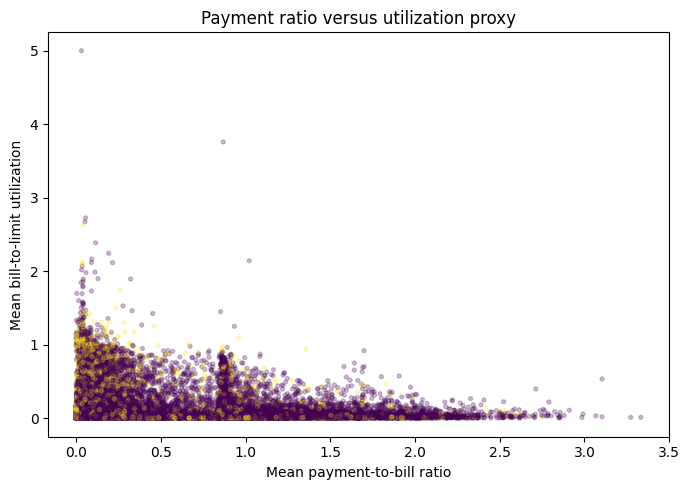

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(features_df["proxy_payment_ratio_mean_6m"], features_df["proxy_utilization_mean_6m"], c=features_df[TARGET], alpha=0.25, s=8)
ax.set_title("Payment ratio versus utilization proxy")
ax.set_xlabel("Mean payment-to-bill ratio")
ax.set_ylabel("Mean bill-to-limit utilization")
save_figure(fig, "03_payment_ratio_vs_utilization.png")
plt.show()

## Clearly synthetic mobile-money event aggregation

The following cell created a small synthetic event table only to test how true mobile-money data could be aggregated. It was not merged into the main public modeling dataset, because the values were not real customer observations.

In [7]:
synthetic_events = create_sample_mobile_money_events(n_customers=20, random_state=42)
synthetic_aggregates = add_synthetic_mobile_money_aggregates(synthetic_events)
save_table(synthetic_aggregates.head(20), "03_synthetic_mobile_money_aggregates_demo.csv")
synthetic_aggregates.head()

,customer_id,mm_topup_count_30d,mm_topup_amount_sum_30d,mm_cash_in_count_30d,mm_cash_out_count_30d,mm_p2p_received_sum_90d,mm_p2p_sent_sum_90d,mm_billpay_count_90d,mm_ussd_sessions_30d
0,1,0.0,0.00,0.0,1.0,1775.08,1782.52,2.0,0.0
1,2,2.0,1140.22,0.0,1.0,0.00,1961.43,0.0,1.0
2,3,0.0,0.00,0.0,0.0,0.00,2694.70,2.0,0.0
3,4,4.0,9441.39,0.0,1.0,11660.76,710.99,1.0,0.0
4,5,1.0,543.19,0.0,0.0,1382.94,1870.87,0.0,1.0


## Saving the modeling dataset

The engineered public-proxy dataset was saved to `data/processed/`. Later notebooks used this table for model training.

In [8]:
processed_path = PROCESSED_DIR / "credit_default_features.csv"
features_df.to_csv(processed_path, index=False)
print(f"Saved engineered modeling dataset to: {processed_path}")

Saved engineered modeling dataset to: C:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\credit-scoring-unbanked-mobile-money\data\processed\credit_default_features.csv
